# Modelagem de prêmio puro em seguro de automóvel com GLM e XGBoost

Rotinas do TCC — MBA em Data Science e Analytics (USP/Esalq).

## 1. Leitura dos dados e análise exploratória

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml

freq = fetch_openml(name="freMTPL2freq", version=1, as_frame=True)
sev = fetch_openml(name="freMTPL2sev", version=1, as_frame=True)

df_freq = freq.frame
df_sev = sev.frame

print(df_freq.shape)
print(df_freq.head())

(678013, 12)
   IDpol  ClaimNb  Exposure Area  VehPower  VehAge  DrivAge  BonusMalus  \
0    1.0        1      0.10    D         5       0       55          50   
1    3.0        1      0.77    D         5       0       55          50   
2    5.0        1      0.75    B         6       2       52          50   
3   10.0        1      0.09    B         7       0       46          50   
4   11.0        1      0.84    B         7       0       46          50   

  VehBrand     VehGas  Density Region  
0      B12  'Regular'     1217    R82  
1      B12  'Regular'     1217    R82  
2      B12   'Diesel'       54    R22  
3      B12   'Diesel'       76    R72  
4      B12   'Diesel'       76    R72  


In [2]:
# Visão geral da base
print("=== FREQUÊNCIA ===")
print(f"Shape: {df_freq.shape}")
print(df_freq.dtypes)
print("\nEstatísticas descritivas:")
print(df_freq.describe())

print("\n=== SEVERIDADE ===")
print(f"Shape: {df_sev.shape}")
print(df_sev.describe())

# Valores nulos
print("\nValores nulos - Frequência:")
print(df_freq.isnull().sum())

=== FREQUÊNCIA ===
Shape: (678013, 12)
IDpol          float64
ClaimNb          int64
Exposure       float64
Area          category
VehPower         int64
VehAge           int64
DrivAge          int64
BonusMalus       int64
VehBrand      category
VehGas             str
Density          int64
Region        category
dtype: object

Estatísticas descritivas:
              IDpol        ClaimNb       Exposure       VehPower  \
count  6.780130e+05  678013.000000  678013.000000  678013.000000   
mean   2.621857e+06       0.053247       0.528750       6.454631   
std    1.641783e+06       0.240117       0.364442       2.050906   
min    1.000000e+00       0.000000       0.002732       4.000000   
25%    1.157951e+06       0.000000       0.180000       5.000000   
50%    2.272152e+06       0.000000       0.490000       6.000000   
75%    4.046274e+06       0.000000       0.990000       7.000000   
max    6.114330e+06      16.000000       2.010000      15.000000   

              VehAge        Dri

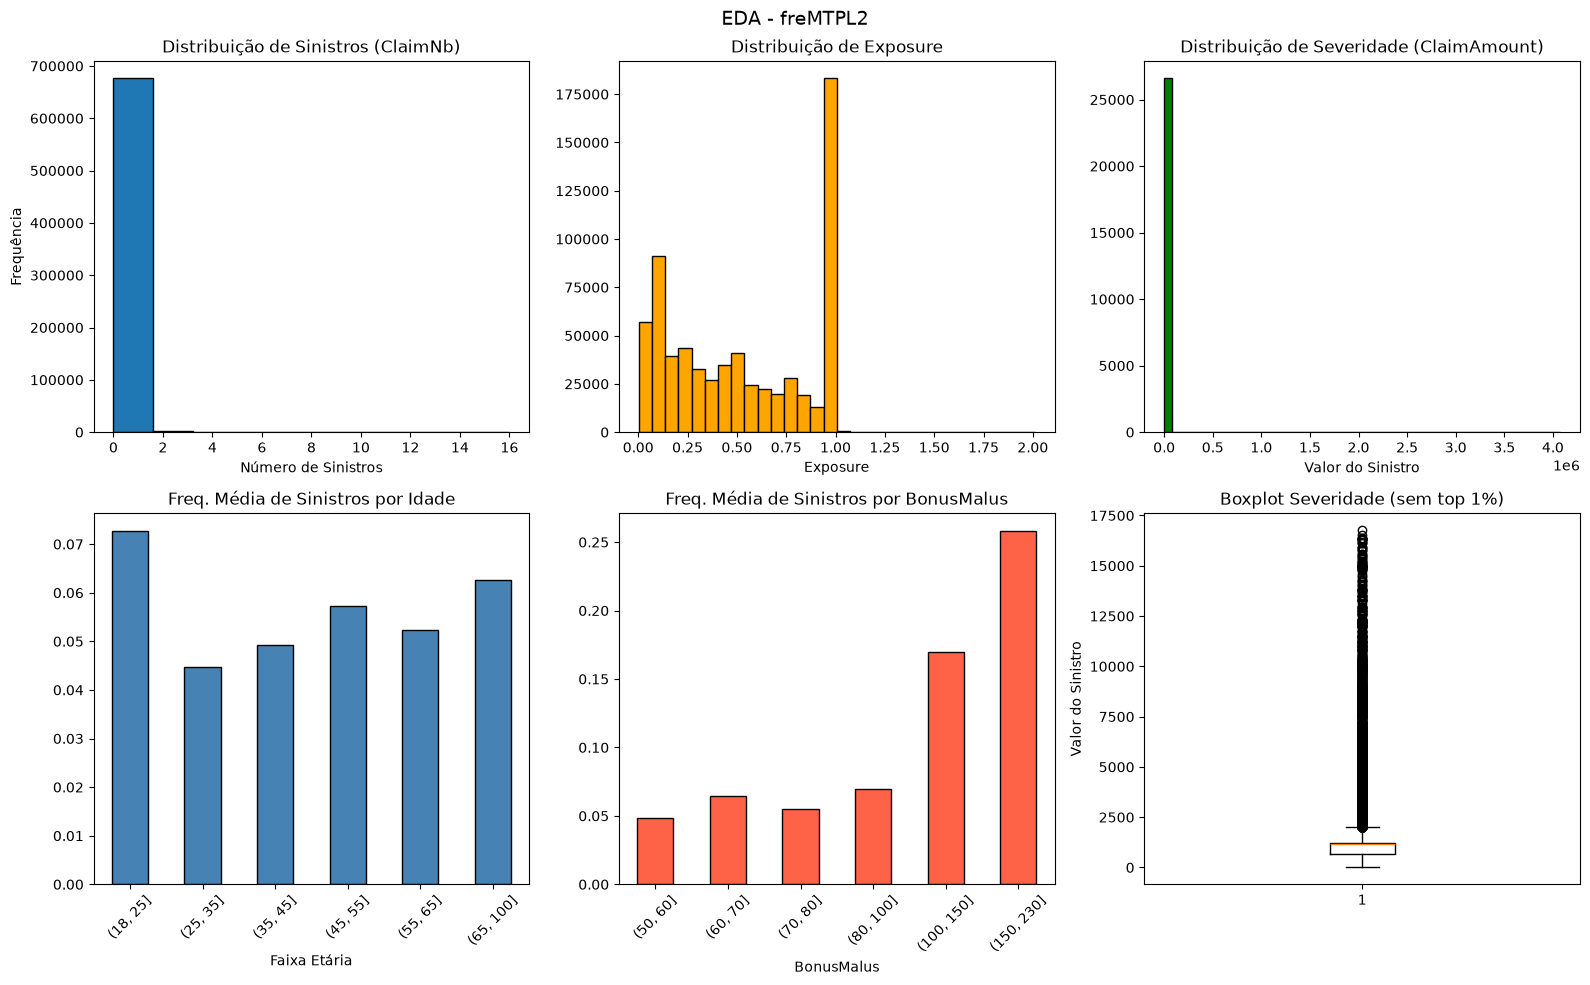

Gráfico salvo!


In [3]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('EDA - freMTPL2', fontsize=14)

# 1. Distribuição de sinistros (ClaimNb)
axes[0,0].hist(df_freq['ClaimNb'], bins=10, edgecolor='black')
axes[0,0].set_title('Distribuição de Sinistros (ClaimNb)')
axes[0,0].set_xlabel('Número de Sinistros')
axes[0,0].set_ylabel('Frequência')

# 2. Distribuição de Exposure
axes[0,1].hist(df_freq['Exposure'], bins=30, edgecolor='black', color='orange')
axes[0,1].set_title('Distribuição de Exposure')
axes[0,1].set_xlabel('Exposure')

# 3. Distribuição de severidade (ClaimAmount)
axes[0,2].hist(df_sev['ClaimAmount'], bins=50, edgecolor='black', color='green')
axes[0,2].set_title('Distribuição de Severidade (ClaimAmount)')
axes[0,2].set_xlabel('Valor do Sinistro')

# 4. Sinistros por faixa de idade do motorista
df_freq['DrivAge_bin'] = pd.cut(df_freq['DrivAge'], bins=[18,25,35,45,55,65,100])
sinistros_idade = df_freq.groupby('DrivAge_bin', observed=True)['ClaimNb'].mean()
sinistros_idade.plot(kind='bar', ax=axes[1,0], color='steelblue', edgecolor='black')
axes[1,0].set_title('Freq. Média de Sinistros por Idade')
axes[1,0].set_xlabel('Faixa Etária')
axes[1,0].tick_params(axis='x', rotation=45)

# 5. Sinistros por BonusMalus
df_freq['BM_bin'] = pd.cut(df_freq['BonusMalus'], bins=[50,60,70,80,100,150,230])
sinistros_bm = df_freq.groupby('BM_bin', observed=True)['ClaimNb'].mean()
sinistros_bm.plot(kind='bar', ax=axes[1,1], color='tomato', edgecolor='black')
axes[1,1].set_title('Freq. Média de Sinistros por BonusMalus')
axes[1,1].set_xlabel('BonusMalus')
axes[1,1].tick_params(axis='x', rotation=45)

# 6. Severidade - boxplot sem outliers extremos
sev_filtrado = df_sev[df_sev['ClaimAmount'] < df_sev['ClaimAmount'].quantile(0.99)]
axes[1,2].boxplot(sev_filtrado['ClaimAmount'])
axes[1,2].set_title('Boxplot Severidade (sem top 1%)')
axes[1,2].set_ylabel('Valor do Sinistro')

plt.tight_layout()
plt.savefig('eda_fremtpl2.png', dpi=150)
plt.show()
print("Gráfico salvo!")

## 2. Preparação e divisão treino/teste

A divisão da severidade é derivada da divisão da frequência: os sinistros das apólices de treino vão para o treino e os das apólices de teste para o teste. Assim, nenhuma apólice usada na avaliação do prêmio puro teve seus sinistros usados no ajuste do modelo de severidade.

In [4]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                             mean_poisson_deviance, mean_gamma_deviance)

# Preparar base (remove as faixas criadas só para os gráficos da EDA)
df_model = df_freq.drop(columns=['DrivAge_bin', 'BM_bin'], errors='ignore').copy()
df_model['VehGas'] = df_model['VehGas'].astype(str).str.replace("'", "").str.strip()
for col in ['Area', 'VehBrand', 'Region']:
    df_model[col] = df_model[col].astype(str)

# Frequência: divisão 80/20 com semente fixa
train, test = train_test_split(df_model, test_size=0.2, random_state=42)
print(f"Frequência -> treino: {train.shape[0]} | teste: {test.shape[0]}")

# Severidade: segue a mesma divisão das apólices
covars = ['IDpol', 'VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'Density',
          'Area', 'VehBrand', 'VehGas', 'Region']
df_sev_model = df_sev.merge(df_model[covars], on='IDpol', how='inner')
ids_treino = set(train['IDpol'])
train_sev = df_sev_model[df_sev_model['IDpol'].isin(ids_treino)].copy()
test_sev = df_sev_model[~df_sev_model['IDpol'].isin(ids_treino)].copy()
print(f"Severidade -> treino: {train_sev.shape[0]} | teste: {test_sev.shape[0]}")

Frequência -> treino: 542410 | teste: 135603
Severidade -> treino: 21044 | teste: 5400


## 3. GLM Poisson — frequência (offset: log da exposição)

In [5]:
glm_freq = smf.glm(
    formula='ClaimNb ~ VehPower + VehAge + DrivAge + BonusMalus + Density + Area + VehBrand + VehGas + Region',
    data=train,
    family=sm.families.Poisson(),
    offset=np.log(train['Exposure'])
).fit()

print(glm_freq.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                ClaimNb   No. Observations:               542410
Model:                            GLM   Df Residuals:                   542367
Model Family:                 Poisson   Df Model:                           42
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.1454e+05
Date:                Wed, 30 Sep 2026   Deviance:                   1.7370e+05
Time:                        15:57:49   Pearson chi2:                 1.42e+06
No. Iterations:                     7   Pseudo R-squ. (CS):            0.01072
Covariance Type:            nonrobust                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            -4.0008      0.05

## 4. GLM Gamma — severidade

In [6]:
glm_sev = smf.glm(
    formula='ClaimAmount ~ VehPower + VehAge + DrivAge + BonusMalus + Density + Area + VehBrand + VehGas + Region',
    data=train_sev,
    family=sm.families.Gamma(link=sm.families.links.Log())
).fit()

print(glm_sev.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            ClaimAmount   No. Observations:                21044
Model:                            GLM   Df Residuals:                    21001
Model Family:                   Gamma   Df Model:                           42
Link Function:                    Log   Scale:                          44.156
Method:                          IRLS   Log-Likelihood:            -2.2616e+05
Date:                Wed, 30 Sep 2026   Deviance:                       34006.
Time:                        15:57:50   Pearson chi2:                 9.27e+05
No. Iterations:                    68   Pseudo R-squ. (CS):           0.003613
Covariance Type:            nonrobust                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             6.9378      0.41

## 5. XGBoost — frequência e severidade

Na frequência, o alvo é a taxa anual de sinistros (`ClaimNb / Exposure`), com ponderação pela exposição — a forma equivalente ao offset do GLM. A predição é depois multiplicada pela exposição de cada apólice, para ficar na mesma escala do número observado de sinistros.

In [7]:
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder

features = ['VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'Density', 'Area', 'VehBrand', 'VehGas', 'Region']
cat_cols = ['Area', 'VehBrand', 'VehGas', 'Region']

# Um único codificador por variável, para treino e teste usarem o mesmo mapeamento
encoders = {c: LabelEncoder().fit(df_model[c].astype(str)) for c in cat_cols}

def encode_cats(df):
    df = df.copy()
    for c in cat_cols:
        df[c] = encoders[c].transform(df[c].astype(str))
    return df

train_enc, test_enc = encode_cats(train), encode_cats(test)
train_sev_enc, test_sev_enc = encode_cats(train_sev), encode_cats(test_sev)

params = dict(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42)

# Frequência: taxa anual, ponderada pela exposição
xgb_freq = xgb.XGBRegressor(objective='count:poisson', **params)
xgb_freq.fit(train_enc[features], train_enc['ClaimNb'] / train_enc['Exposure'],
             sample_weight=train_enc['Exposure'])

# Severidade
xgb_sev = xgb.XGBRegressor(objective='reg:gamma', **params)
xgb_sev.fit(train_sev_enc[features], train_sev_enc['ClaimAmount'])
print("Modelos XGBoost ajustados.")

Modelos XGBoost ajustados.


## 6. Avaliação no conjunto de teste

Todas as métricas, inclusive a deviance, são calculadas no conjunto de teste e para os dois modelos. A deviance é reportada como média por observação (Poisson na frequência, Gamma na severidade).

In [8]:
# --- Frequência: número esperado de sinistros no período de exposição de cada apólice
expo_test = test['Exposure'].values
y_freq = test['ClaimNb'].values
freq_glm = np.asarray(glm_freq.predict(test, offset=np.log(test['Exposure'])))
freq_xgb = xgb_freq.predict(test_enc[features]) * expo_test

# --- Severidade: custo por sinistro
y_sev = test_sev['ClaimAmount'].values
sev_glm = np.asarray(glm_sev.predict(test_sev))
sev_xgb = xgb_sev.predict(test_sev_enc[features])

# --- Prêmio puro: perda observada por apólice no período (soma dos sinistros) x predição freq * sev
perdas = df_sev.groupby('IDpol')['ClaimAmount'].sum()
y_pp = test['IDpol'].map(perdas).fillna(0).values
pp_glm = freq_glm * np.asarray(glm_sev.predict(test))
pp_xgb = freq_xgb * xgb_sev.predict(test_enc[features])

def linha(componente, metrica, f, y, p_glm, p_xgb):
    return {'Componente': componente, 'Métrica': metrica, 'GLM': f(y, p_glm), 'XGBoost': f(y, p_xgb)}

razao = lambda y, p: p.sum() / y.sum()

tabela = pd.DataFrame([
    linha('Frequência', 'MSE', mean_squared_error, y_freq, freq_glm, freq_xgb),
    linha('Frequência', 'MAE', mean_absolute_error, y_freq, freq_glm, freq_xgb),
    linha('Frequência', 'Deviance média (Poisson)', mean_poisson_deviance, y_freq, freq_glm, freq_xgb),
    linha('Frequência', 'Razão predito/observado', razao, y_freq, freq_glm, freq_xgb),
    linha('Severidade', 'MSE', mean_squared_error, y_sev, sev_glm, sev_xgb),
    linha('Severidade', 'MAE', mean_absolute_error, y_sev, sev_glm, sev_xgb),
    linha('Severidade', 'Deviance média (Gamma)', mean_gamma_deviance, y_sev, sev_glm, sev_xgb),
    linha('Prêmio puro', 'MSE', mean_squared_error, y_pp, pp_glm, pp_xgb),
    linha('Prêmio puro', 'MAE', mean_absolute_error, y_pp, pp_glm, pp_xgb),
    linha('Prêmio puro', 'Razão predito/observado', razao, y_pp, pp_glm, pp_xgb),
])
tabela['Variação XGBoost vs GLM (%)'] = (tabela['XGBoost'] / tabela['GLM'] - 1) * 100

pd.set_option('display.float_format', lambda v: f'{v:,.4f}')
print(tabela.to_string(index=False))

print(f"\nFrequência média observada no teste: {y_freq.mean():.4f}")
print(f"Frequência média predita - GLM: {freq_glm.mean():.4f} | XGBoost: {freq_xgb.mean():.4f}")
print(f"Perda média observada por apólice: {y_pp.mean():.2f}")
print(f"Prêmio puro médio predito - GLM: {pp_glm.mean():.2f} | XGBoost: {pp_xgb.mean():.2f}")

 Componente                  Métrica              GLM          XGBoost  Variação XGBoost vs GLM (%)
 Frequência                      MSE           0.0563           0.0555                      -1.3919
 Frequência                      MAE           0.0989           0.0973                      -1.6503
 Frequência Deviance média (Poisson)           0.3216           0.3078                      -4.2984
 Frequência  Razão predito/observado           0.9938           0.9916                      -0.2184
 Severidade                      MSE 199,266,740.0344 199,221,869.5429                      -0.0225
 Severidade                      MAE       2,194.9614       1,895.7340                     -13.6325
 Severidade   Deviance média (Gamma)           1.8599           1.7843                      -4.0639
Prêmio puro                      MSE   8,189,310.7251   8,184,893.7174                      -0.0539
Prêmio puro                      MAE         190.7598         171.2514                     -10.2267


## 7. Importância de variáveis (XGBoost)

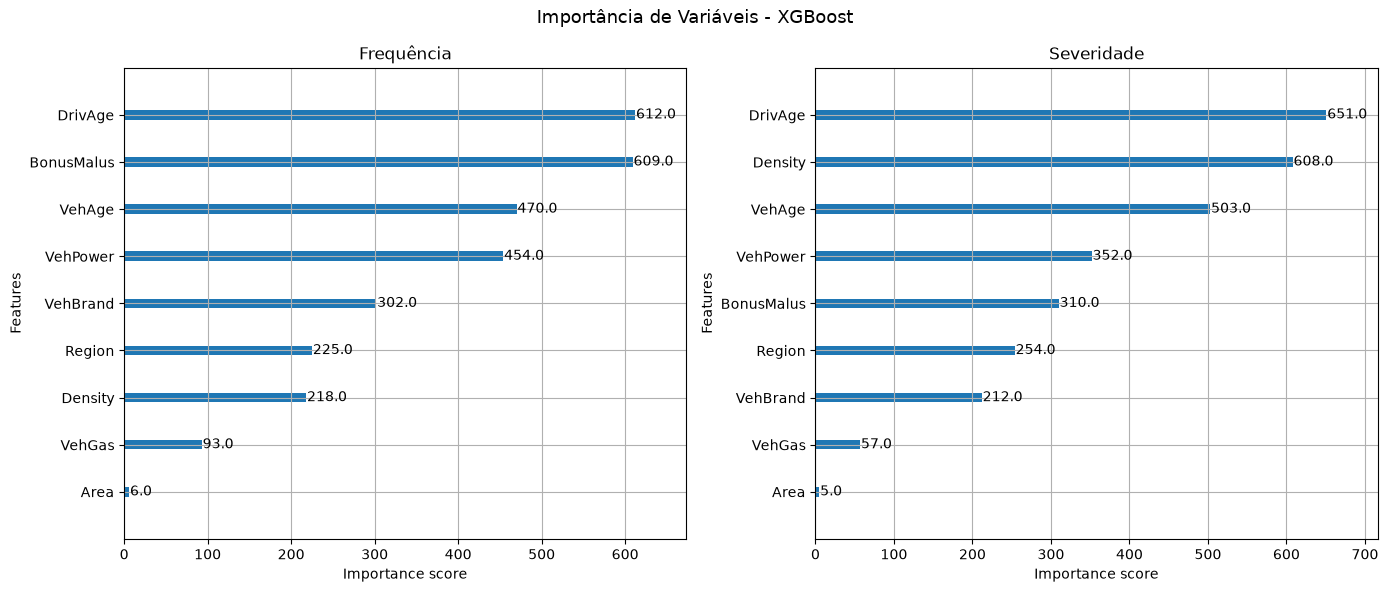

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Importância de Variáveis - XGBoost', fontsize=13)
xgb.plot_importance(xgb_freq, ax=axes[0], max_num_features=10, title='Frequência')
xgb.plot_importance(xgb_sev, ax=axes[1], max_num_features=10, title='Severidade')
plt.tight_layout()
plt.savefig('importancia_variaveis.png', dpi=150)
plt.show()

## 8. Ambiente

In [10]:
import sys
import pandas as pd
import sklearn
import statsmodels
import xgboost
import matplotlib

print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("statsmodels:", statsmodels.__version__)
print("xgboost:", xgboost.__version__)
print("matplotlib:", matplotlib.__version__)

Python: 3.13.5
pandas: 3.0.3
scikit-learn: 1.9.0
statsmodels: 0.14.6
xgboost: 3.2.0
matplotlib: 3.11.0
